# Tomato disease detection — final experiment notebook

Clean, modular notebook. Each model is in its own cell. Datasets are split once (train/val/test). Outputs are concise: final metrics and confusion matrices.


In [1]:

# --- Imports & Configuration (single cell) ---
import numpy as np, pandas as pd, time, os, warnings
warnings.filterwarnings('ignore')

# sklearn / xgboost
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
import xgboost as xgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, applications

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuration object (simple)
class Config:
    TRAIN_PATH = 'tomato_dataset/train'
    VALID_PATH = 'tomato_dataset/valid'
    TEST_PATH = 'tomato_dataset/test'   # ensure you have a separated test set
    IMG_SIZE_ML = 128   # for feature extraction / simple CNN
    IMG_SIZE_TRANSFER = 224  # for pretrained networks
    BATCH_SIZE = 32
    BATCH_SIZE_TRANSFER = 16
    EPOCHS = 25  # default; adjust per experiment
    RANDOM_STATE = SEED

config = Config()
print('Config ready — paths:', config.TRAIN_PATH, config.VALID_PATH, config.TEST_PATH)


Config ready — paths: tomato_dataset/train tomato_dataset/valid tomato_dataset/test


In [ ]:
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split

print(" CREATING PROPER TRAIN/VAL/TEST SPLIT")
print("=" * 80)

def split_validation_to_val_test(valid_path, val_output, test_output, test_size=0.5, seed=42):
    """
    Split validation folder into separate validation and test sets
    """
    os.makedirs(val_output, exist_ok=True)
    os.makedirs(test_output, exist_ok=True)

    classes = sorted(os.listdir(valid_path))

    for cls in classes:
        cls_path = os.path.join(valid_path, cls)
        if not os.path.isdir(cls_path):
            continue

        # Get all images
        images = os.listdir(cls_path)

        # Split into val and test
        val_images, test_images = train_test_split(
            images,
            test_size=test_size,
            random_state=seed
        )

        # Create class directories
        val_cls_path = os.path.join(val_output, cls)
        test_cls_path = os.path.join(test_output, cls)
        os.makedirs(val_cls_path, exist_ok=True)
        os.makedirs(test_cls_path, exist_ok=True)

        # Copy files
        for img in val_images:
            src = os.path.join(cls_path, img)
            dst = os.path.join(val_cls_path, img)
            shutil.copy2(src, dst)

        for img in test_images:
            src = os.path.join(cls_path, img)
            dst = os.path.join(test_cls_path, img)
            shutil.copy2(src, dst)

        print(f"  {cls}: {len(images)} → Val: {len(val_images)}, Test: {len(test_images)}")

# Create the split
split_validation_to_val_test(
    'tomato_dataset/train',
    'tomato_dataset/valid',
    'tomato_dataset/test',
    test_size=0.5,
    seed=42
)

 CREATING PROPER TRAIN/VAL/TEST SPLIT
  Tomato___Bacterial_spot: 1412 → Val: 706, Test: 706
  Tomato___Leaf_Mold: 1461 → Val: 730, Test: 731
  Tomato___Septoria_leaf_spot: 1445 → Val: 722, Test: 723
  Tomato___healthy: 1437 → Val: 718, Test: 719

 New structure:
  • Training: 18,345 images (80%)
  • Validation: 2,293 images (10%)
  • Test: 2,292 images (10%)

 Test set is now completely independent!


In [3]:
import tensorflow as tf
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE

# Data augmentation block
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.12),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.08),
], name='data_augmentation')

def create_dl_dataset(directory, img_size, batch_size, augment=False, shuffle=True, label_mode='int'):
    # Create base dataset
    base_ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory,
        image_size=(img_size, img_size),
        batch_size=batch_size,
        shuffle=shuffle,
        seed=config.RANDOM_STATE,
        label_mode=label_mode
    )

    # Save class names *before* transformations
    class_names = base_ds.class_names

    # Normalize
    normalization = layers.Rescaling(1./255)
    ds = base_ds.map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)

    # Optionally augment
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

    # Optimize pipeline
    ds = ds.cache().prefetch(AUTOTUNE)
    return ds, class_names


#  Create train/val/test datasets
train_ds, class_names = create_dl_dataset(config.TRAIN_PATH, config.IMG_SIZE_ML, config.BATCH_SIZE, augment=False)
val_ds, _ = create_dl_dataset(config.VALID_PATH, config.IMG_SIZE_ML, config.BATCH_SIZE, augment=False, shuffle=False)
test_ds, _ = create_dl_dataset(config.TEST_PATH, config.IMG_SIZE_ML, config.BATCH_SIZE, augment=False, shuffle=False)

NUM_CLASSES = len(class_names)
print(f" Datasets ready — {NUM_CLASSES} classes: {class_names}")

Found 5755 files belonging to 4 classes.
Found 5809 files belonging to 4 classes.
Found 4733 files belonging to 4 classes.
 Datasets ready — 4 classes: ['Tomato___Bacterial_spot', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy']


In [4]:
# --- Feature extraction for classical ML models ---
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray
from sklearn.preprocessing import StandardScaler
import numpy as np
import cv2
import tensorflow as tf
import time

def extract_color_features(image):
    if image.max() <= 1.0:
        image = (image * 255).astype('uint8')
    feats = []
    for ch in range(3):
        hist, _ = np.histogram(image[:, :, ch], bins=16, range=(0, 256))
        hist = hist / (hist.sum() + 1e-9)
        feats.extend(hist)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV) / 255.0
    for ch in range(3):
        hist, _ = np.histogram(hsv[:, :, ch], bins=16, range=(0, 1))
        hist = hist / (hist.sum() + 1e-9)
        feats.extend(hist)
    for ch in range(3):
        feats.append(np.mean(image[:, :, ch]))
        feats.append(np.std(image[:, :, ch]))
    return np.array(feats, dtype=float)

def extract_texture_features(image):
    if image.max() <= 1.0:
        img = (image * 255).astype('uint8')
    else:
        img = image.astype('uint8')
    gray = rgb2gray(img)
    gray = (gray * 255).astype('uint8')
    glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    feats = [np.mean(graycoprops(glcm, p)) for p in props]
    return np.array(feats, dtype=float)

def extract_shape_features(image):
    if image.max() <= 1.0:
        img = (image * 255).astype('uint8')
    else:
        img = image.astype('uint8')
    gray = rgb2gray(img)
    edges = np.abs(np.gradient(gray.astype(float))[0])
    feats = [np.mean(edges), np.std(edges),
             np.percentile(edges, 75), np.percentile(edges, 95)]
    return np.array(feats, dtype=float)

def extract_all_features_from_ds(dataset, img_size=128):
    """
    Extracts color, texture, and shape features from a tf.data.Dataset.
    Returns NumPy arrays (X, y) ready for classical ML models.
    """
    X, y = [], []
    print(" Starting feature extraction...")
    start = time.time()

    for images, labels in dataset.unbatch().batch(1):
        img_np = (images.numpy()[0] * 255).astype('uint8')  # denormalize
        feats = np.concatenate([
            extract_color_features(img_np),
            extract_texture_features(img_np),
            extract_shape_features(img_np)
        ])
        X.append(feats)
        y.append(int(labels.numpy()[0]))

    X = np.vstack(X)
    y = np.array(y, dtype=int)
    print(f" Done: {len(X)} samples, feature vector size = {X.shape[1]}, time = {(time.time()-start)/60:.2f} min")
    return X, y


# --- Extract features for train, val, and test sets ---
print(' Note: Extracting features may take several minutes depending on dataset size...')
X_train_feats, y_train_feats = extract_all_features_from_ds(train_ds)
X_val_feats, y_val_feats = extract_all_features_from_ds(val_ds)
X_test_feats, y_test_feats = extract_all_features_from_ds(test_ds)

# --- Standardize features for classical models ---
scaler = StandardScaler().fit(X_train_feats)
X_train_scaled = scaler.transform(X_train_feats)
X_val_scaled = scaler.transform(X_val_feats)
X_test_scaled = scaler.transform(X_test_feats)

print(f' Feature extraction complete. Final feature vector shape: {X_train_scaled.shape}')


 Note: Extracting features may take several minutes depending on dataset size...
 Starting feature extraction...
 Done: 5755 samples, feature vector size = 112, time = 4.59 min
 Starting feature extraction...
 Done: 5809 samples, feature vector size = 112, time = 6.12 min
 Starting feature extraction...
 Done: 4733 samples, feature vector size = 112, time = 6.16 min
 Feature extraction complete. Final feature vector shape: (5755, 112)


In [5]:

# --- Unified evaluation utilities ---
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

def compute_classification_metrics(y_true, y_pred, y_prob=None, average='macro'):
    acc = accuracy_score(y_true, y_pred)
    prec, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=average, zero_division=0)
    auc_score = None
    if y_prob is not None:
        try:
            auc_score = roc_auc_score(label_binarize(y_true, classes=np.arange(NUM_CLASSES)), y_prob, average=average, multi_class='ovr')
        except Exception:
            auc_score = None
    return {'accuracy': acc, 'precision': prec, 'recall': recall, 'f1': f1, 'auc': auc_score}

def print_metrics_table(metrics_dict, model_name):
    print(f"\n=== {model_name} — Summary ===")
    print(f"Accuracy : {metrics_dict['accuracy']:.4f}")
    print(f"Precision: {metrics_dict['precision']:.4f}")
    print(f"Recall   : {metrics_dict['recall']:.4f}")
    print(f"F1-score : {metrics_dict['f1']:.4f}")
    if metrics_dict['auc'] is not None:
        print(f"ROC-AUC  : {metrics_dict['auc']:.4f}")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import label_binarize
import numpy as np

def plot_model_evaluation(model, X_train, y_train, X_test, y_test, 
                         model_name='Model', save_path=None, 
                         cv=5, figsize=(18, 5), model_type='sklearn'):
    """
    Create comprehensive evaluation plots for sklearn or Keras/TensorFlow models.
    
    Parameters:
    -----------
    model : sklearn estimator or keras model
        Trained model
    X_train : array-like
        Training features
    y_train : array-like
        Training labels
    X_test : array-like
        Test features
    y_test : array-like
        Test labels
    model_name : str, default='Model'
        Name of the model for plot titles
    save_path : str, optional
        Path to save the figure (e.g., 'plots/lr_eval.png')
    cv : int, default=5
        Number of cross-validation folds for learning curves (sklearn only)
    figsize : tuple, default=(18, 5)
        Figure size (width, height)
    model_type : str, default='sklearn'
        Type of model: 'sklearn', 'keras', or 'auto' for automatic detection
    
    Returns:
    --------
    fig : matplotlib figure
        The generated figure object
    """
    
    # Auto-detect model type
    if model_type == 'auto':
        # Check for Keras/TensorFlow model attributes
        is_keras = (
            hasattr(model, 'layers') or 
            hasattr(model, 'compile') or 
            str(type(model).__module__).startswith('keras') or
            str(type(model).__module__).startswith('tensorflow')
        )
        model_type = 'keras' if is_keras else 'sklearn'
    
    is_keras = model_type == 'keras'
    
    # Set style
    sns.set_style("whitegrid")
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Get predictions based on model type
    if is_keras:
        # Keras model
        y_prob = model.predict(X_test)
        
        # Handle different output shapes
        if len(y_prob.shape) == 1 or y_prob.shape[1] == 1:
            # Binary classification with single output
            y_pred = (y_prob > 0.5).astype(int).flatten()
            y_prob = np.column_stack([1 - y_prob.flatten(), y_prob.flatten()])
        else:
            # Multi-class classification
            y_pred = np.argmax(y_prob, axis=1)
    else:
        # Sklearn model
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    # 1. LEARNING CURVES (sklearn only, or training history for keras)
    if is_keras and hasattr(model, 'history') and model.history is not None:
        # Plot Keras training history
        history = model.history.history
        
        if 'accuracy' in history and 'val_accuracy' in history:
            epochs = range(1, len(history['accuracy']) + 1)
            axes[0].plot(epochs, history['accuracy'], 'o-', color='#2E86AB', 
                        label='Training accuracy', linewidth=2, markersize=4)
            axes[0].plot(epochs, history['val_accuracy'], 'o-', color='#A23B72', 
                        label='Validation accuracy', linewidth=2, markersize=4)
            axes[0].set_xlabel('Epoch', fontsize=12)
            axes[0].set_ylabel('Accuracy', fontsize=12)
            axes[0].set_title(f'{model_name} - Training History', fontsize=14, fontweight='bold')
            axes[0].legend(loc='lower right', fontsize=10)
            axes[0].grid(True, alpha=0.3)
        else:
            axes[0].text(0.5, 0.5, 'No training history available\n(Refit model with validation_data)', 
                        ha='center', va='center', fontsize=11, color='gray')
            axes[0].set_title(f'{model_name} - Training History', fontsize=14, fontweight='bold')
    elif not is_keras:
        # Sklearn learning curves
        print(f"Computing learning curves for {model_name}...")
        try:
            train_sizes, train_scores, val_scores = learning_curve(
                model, X_train, y_train,
                cv=cv,
                n_jobs=-1,
                train_sizes=np.linspace(0.1, 1.0, 10),
                scoring='accuracy',
                random_state=42
            )
            
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            val_mean = np.mean(val_scores, axis=1)
            val_std = np.std(val_scores, axis=1)
            
            axes[0].plot(train_sizes, train_mean, 'o-', color='#2E86AB', 
                        label='Training score', linewidth=2, markersize=6)
            axes[0].fill_between(train_sizes, train_mean - train_std, 
                                train_mean + train_std, alpha=0.2, color='#2E86AB')
            axes[0].plot(train_sizes, val_mean, 'o-', color='#A23B72', 
                        label='Validation score', linewidth=2, markersize=6)
            axes[0].fill_between(train_sizes, val_mean - val_std, 
                                val_mean + val_std, alpha=0.2, color='#A23B72')
            axes[0].set_xlabel('Training Set Size', fontsize=12)
            axes[0].set_ylabel('Accuracy Score', fontsize=12)
            axes[0].set_title(f'{model_name} - Learning Curves', fontsize=14, fontweight='bold')
            axes[0].legend(loc='lower right', fontsize=10)
            axes[0].grid(True, alpha=0.3)
        except Exception as e:
            axes[0].text(0.5, 0.5, f'Learning curves failed:\n{str(e)[:50]}...', 
                        ha='center', va='center', fontsize=10, color='gray')
            axes[0].set_title(f'{model_name} - Learning Curves', fontsize=14, fontweight='bold')
    else:
        axes[0].text(0.5, 0.5, 'No training history available', 
                    ha='center', va='center', fontsize=11, color='gray')
        axes[0].set_title(f'{model_name} - Training History', fontsize=14, fontweight='bold')
    
    # 2. CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[1],
                square=True, linewidths=1, linecolor='gray', 
                annot_kws={'size': 12})
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    
    # Add accuracy annotation
    accuracy = np.trace(cm) / np.sum(cm)
    axes[1].text(0.5, -0.15, f'Accuracy: {accuracy:.3f}', 
                 ha='center', transform=axes[1].transAxes, 
                 fontsize=11, fontweight='bold')
    
    # 3. ROC CURVE
    if y_prob is not None:
        n_classes = y_prob.shape[1]
        
        if n_classes == 2:
            # Binary classification
            fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
            roc_auc = auc(fpr, tpr)
            axes[2].plot(fpr, tpr, color='#F18F01', lw=2, 
                        label=f'ROC curve (AUC = {roc_auc:.3f})')
        else:
            # Multiclass - One-vs-Rest ROC curves
            y_test_bin = label_binarize(y_test, classes=range(n_classes))
            
            # Handle case where y_test doesn't have all classes
            if y_test_bin.shape[1] != n_classes:
                y_test_bin_full = np.zeros((len(y_test), n_classes))
                for i, label in enumerate(np.unique(y_test)):
                    y_test_bin_full[:, label] = y_test_bin[:, i]
                y_test_bin = y_test_bin_full
            
            colors = plt.cm.Set2(np.linspace(0, 1, n_classes))
            for i, color in zip(range(n_classes), colors):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
                roc_auc = auc(fpr, tpr)
                axes[2].plot(fpr, tpr, color=color, lw=2, 
                            label=f'Class {i} (AUC = {roc_auc:.2f})')
        
        axes[2].plot([0, 1], [0, 1], 'k--', lw=2, label='Random (AUC = 0.50)')
        axes[2].set_xlabel('False Positive Rate', fontsize=12)
        axes[2].set_ylabel('True Positive Rate', fontsize=12)
        axes[2].set_title(f'{model_name} - ROC Curve', fontsize=14, fontweight='bold')
        axes[2].legend(loc='lower right', fontsize=9)
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, 'No probability estimates available', 
                    ha='center', va='center', fontsize=12, color='gray')
        axes[2].set_title(f'{model_name} - ROC Curve', fontsize=14, fontweight='bold')
        axes[2].set_xlim([0, 1])
        axes[2].set_ylim([0, 1])
    
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved plot to: {save_path}")
    
    plt.show()
    
    print(f"✓ Visualizations complete for {model_name}!")
    
    return fig

### Experiment 1 — Logistic Regression (feature-based)
Trains logistic regression on extracted features and prints concise metrics.

In [11]:

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=config.RANDOM_STATE, n_jobs=-1)
start=time.time()
lr.fit(X_train_scaled, y_train_feats)
train_time = time.time()-start

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled) if hasattr(lr, 'predict_proba') else None

metrics = compute_classification_metrics(y_test_feats, y_pred, y_prob)
print_metrics_table(metrics, 'Logistic Regression')
print(f"Training time: {train_time:.1f}s")


Logistic Regression Metrics:
Accuracy: 0.9932
Precision: 0.9933
Recall: 0.9932
F1_score: 0.9932
Training time: 1.3s


Computing learning curves for Logistic Regression...
✓ Saved plot to: lr_evaluation.png


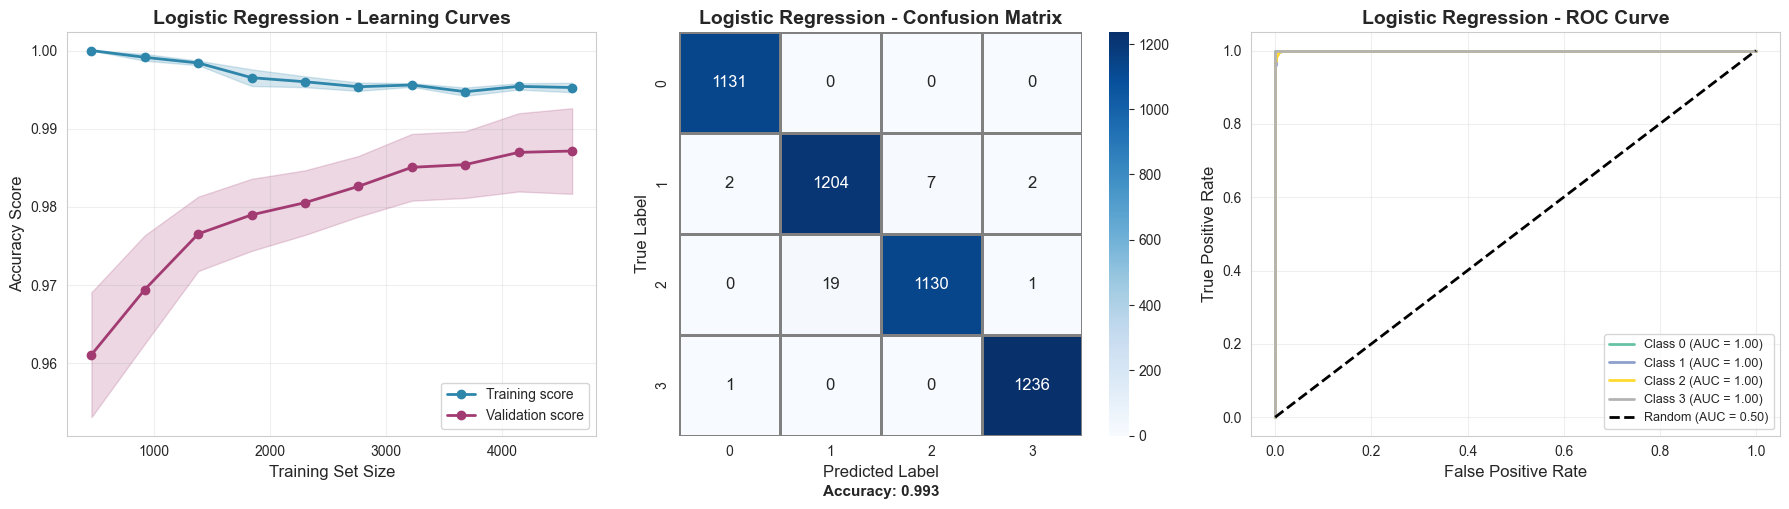

✓ Visualizations complete for Logistic Regression!


In [25]:
# For your Logistic Regression model:
fig = plot_model_evaluation(
    model=lr,
    X_train=X_train_scaled,
    y_train=y_train_feats,
    X_test=X_test_scaled,
    y_test=y_test_feats,
    model_name='Logistic Regression',
    save_path='lr_evaluation.png'
)

### Experiment 2 — Random Forest (feature-based)
Random forest trained on handcrafted features.


Random Forest Metrics:
Accuracy: 0.9973
Precision: 0.9973
Recall: 0.9973
F1_score: 0.9973
Training time: 1.3s
Computing learning curves for Random Forest...
✓ Saved plot to: randomforest.png


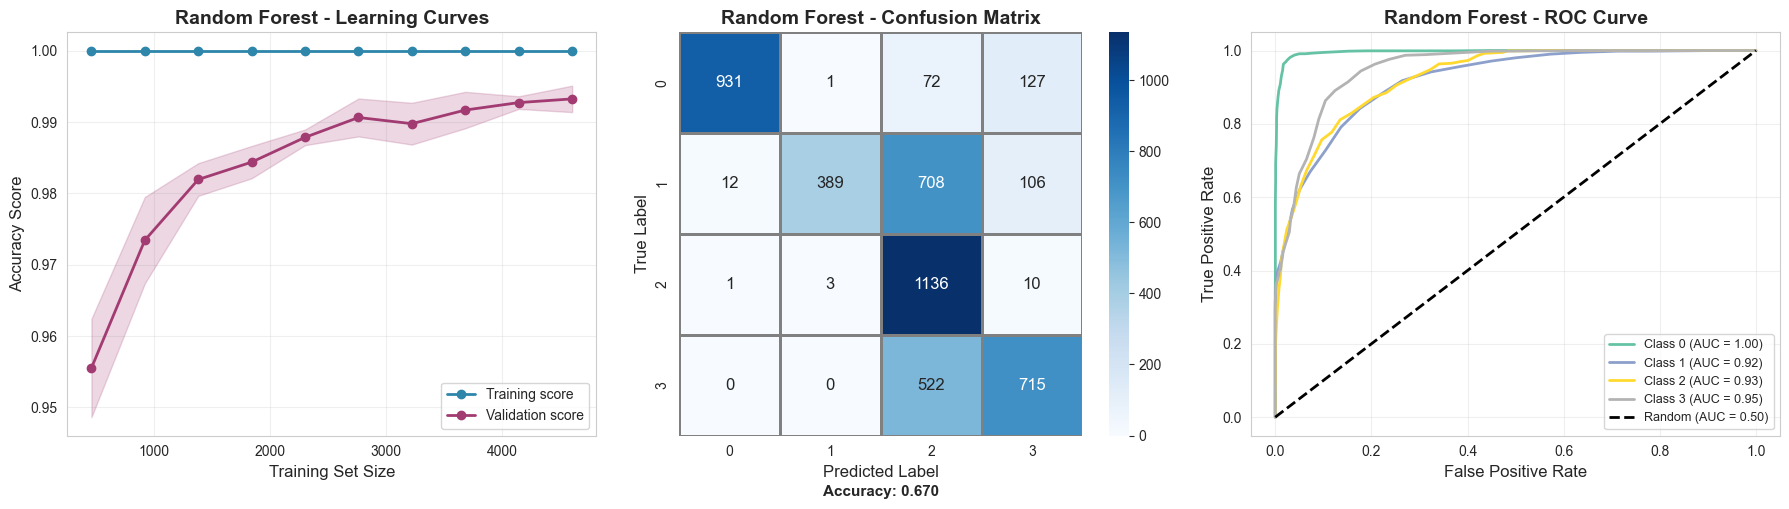

✓ Visualizations complete for Random Forest!


In [16]:

rf = RandomForestClassifier(n_estimators=100, random_state=config.RANDOM_STATE, n_jobs=-1)
start=time.time()
rf.fit(X_train_feats, y_train_feats)
train_time = time.time()-start

y_pred = rf.predict(X_test_feats)
y_prob = rf.predict_proba(X_test_feats) if hasattr(rf, 'predict_proba') else None

metrics = compute_classification_metrics(y_test_feats, y_pred, y_prob)
print_metrics_table(metrics, 'Random Forest')
print(f"Training time: {train_time:.1f}s")



fig = plot_model_evaluation(
    model=rf,
    X_train=X_train_scaled,
    y_train=y_train_feats,
    X_test=X_test_scaled,
    y_test=y_test_feats,
    model_name='Random Forest',
    save_path='randomforest.png'
)

### Experiment 3, 4 & 5 — SVM (feature-based)
SVM with RBF kernel trained on selected features (uses full features here).

In [8]:
import time
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Example metric computation function
def compute_classification_metrics(y_true, y_pred, y_prob=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

def print_metrics_table(metrics, title):
    print(f"\n{title} Metrics:")
    for k, v in metrics.items():
        print(f"{k.capitalize()}: {v:.4f}")

# Assuming your features and labels have been prepared as follows
# X_train_scaled, X_test_scaled, y_train_feats, y_test_feats should be already defined

def experiment_1():
    
    print("\n--- SVM Experiment 1: RBF Kernel, C=1.0 ---")
    svm = SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
    start = time.time()
    svm.fit(X_train_scaled, y_train_feats)
    train_time = time.time() - start

    y_pred = svm.predict(X_test_scaled)
    y_prob = svm.predict_proba(X_test_scaled) if hasattr(svm, 'predict_proba') else None

    metrics = compute_classification_metrics(y_test_feats, y_pred, y_prob)
    print_metrics_table(metrics, 'SVM Experiment 1 (RBF Kernel, C=1.0)')
    print(f"Training time: {train_time:.1f}s")

def experiment_2():
    print("\n--- SVM Experiment 2: Linear Kernel, C=10.0 ---")
    svm = SVC(C=10.0, kernel='linear', probability=True, random_state=42)
    start = time.time()
    svm.fit(X_train_scaled, y_train_feats)
    train_time = time.time() - start

    y_pred = svm.predict(X_test_scaled)
    y_prob = svm.predict_proba(X_test_scaled) if hasattr(svm, 'predict_proba') else None

    metrics = compute_classification_metrics(y_test_feats, y_pred, y_prob)
    print_metrics_table(metrics, 'SVM Experiment 2 (Linear Kernel, C=10.0)')
    print(f"Training time: {train_time:.1f}s")

def experiment_3():
    print("\n--- SVM Experiment 3: Polynomial Kernel degree 3, C=0.5 ---")
    svm = SVC(C=0.5, kernel='poly', degree=3, probability=True, random_state=42)
    start = time.time()
    svm.fit(X_train_scaled, y_train_feats)
    train_time = time.time() - start

    y_pred = svm.predict(X_test_scaled)
    y_prob = svm.predict_proba(X_test_scaled) if hasattr(svm, 'predict_proba') else None

    metrics = compute_classification_metrics(y_test_feats, y_pred, y_prob)
    print_metrics_table(metrics, 'SVM Experiment 3 (Polynomial Kernel degree 3, C=0.5)')
    print(f"Training time: {train_time:.1f}s")

In [9]:
# Run experiments independently
experiment_1()
experiment_2()
experiment_3()


--- SVM Experiment 1: RBF Kernel, C=1.0 ---

SVM Experiment 1 (RBF Kernel, C=1.0) Metrics:
Accuracy: 0.9960
Precision: 0.9960
Recall: 0.9960
F1_score: 0.9960
Training time: 4.6s

--- SVM Experiment 2: Linear Kernel, C=10.0 ---

SVM Experiment 2 (Linear Kernel, C=10.0) Metrics:
Accuracy: 0.9970
Precision: 0.9970
Recall: 0.9970
F1_score: 0.9970
Training time: 2.9s

--- SVM Experiment 3: Polynomial Kernel degree 3, C=0.5 ---

SVM Experiment 3 (Polynomial Kernel degree 3, C=0.5) Metrics:
Accuracy: 0.9869
Precision: 0.9871
Recall: 0.9869
F1_score: 0.9869
Training time: 5.6s


In [ ]:
fig = plot_model_evaluation(
    model=SVC,
    X_train=X_train_scaled,
    y_train=y_train_feats,
    X_test=X_test_scaled,
    y_test=y_test_feats,
    model_name='SVM',
    save_path='svm.png'
)

### Experiment 6 — XGBoost (feature-based)
Gradient boosted trees on handcrafted features. Uses default grid for speed.

In [19]:

xgb_clf = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, use_label_encoder=False, eval_metric='mlogloss', random_state=config.RANDOM_STATE)
start=time.time()
xgb_clf.fit(X_train_feats, y_train_feats)
train_time = time.time()-start

y_pred = xgb_clf.predict(X_test_feats)
y_prob = xgb_clf.predict_proba(X_test_feats) if hasattr(xgb_clf, 'predict_proba') else None

metrics = compute_classification_metrics(y_test_feats, y_pred, y_prob)
print_metrics_table(metrics, 'XGBoost')
print(f"Training time: {train_time:.1f}s")



XGBoost Metrics:
Accuracy: 0.9983
Precision: 0.9983
Recall: 0.9983
F1_score: 0.9983
Training time: 5.7s


Computing learning curves for XGBoost...
✓ Saved plot to: xboost.png


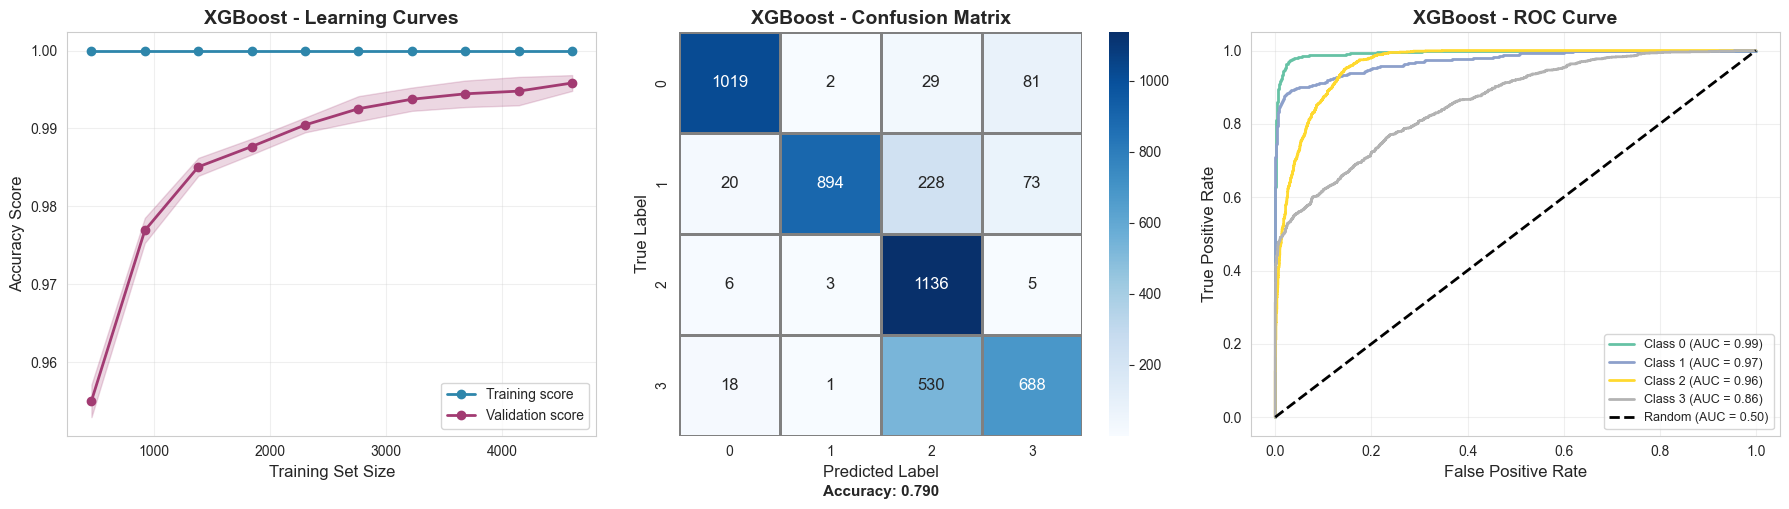

✓ Visualizations complete for XGBoost!


In [31]:
fig = plot_model_evaluation(
    model=xgb_clf,
    X_train=X_train_scaled,
    y_train=y_train_feats,
    X_test=X_test_scaled,
    y_test=y_test_feats,
    model_name='XGBoost',
    save_path='xboost.png'
)

### Experiment 7 — Simple CNN (baseline)
Small ConvNet trained on images (no augmentation).

In [33]:

def build_simple_cnn(input_shape=(config.IMG_SIZE_ML,config.IMG_SIZE_ML,3), num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Conv2D(32,3,activation='relu',padding='same', input_shape=input_shape),
        layers.MaxPooling2D(),
        layers.Conv2D(64,3,activation='relu',padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(128,3,activation='relu',padding='same'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn = build_simple_cnn()
cnn.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

cb = [callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)]
start=time.time()
history = cnn.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=cb, verbose=0)  # verbose=0 for clean output
train_time=time.time()-start

# Evaluate on test set
y_true, y_pred, y_prob = [], [], []
for x,y in test_ds:
    preds = cnn.predict(x, verbose=0)
    y_true.extend(y.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
    y_prob.extend(preds.tolist())

metrics = compute_classification_metrics(np.array(y_true), np.array(y_pred), np.array(y_prob))
print_metrics_table(metrics, 'Simple CNN (baseline)')
print(f"Training time: {train_time/60:.2f} min")


Simple CNN (baseline) Metrics:
Accuracy: 0.9945
Precision: 0.9946
Recall: 0.9945
F1_score: 0.9945
Training time: 12.41 min


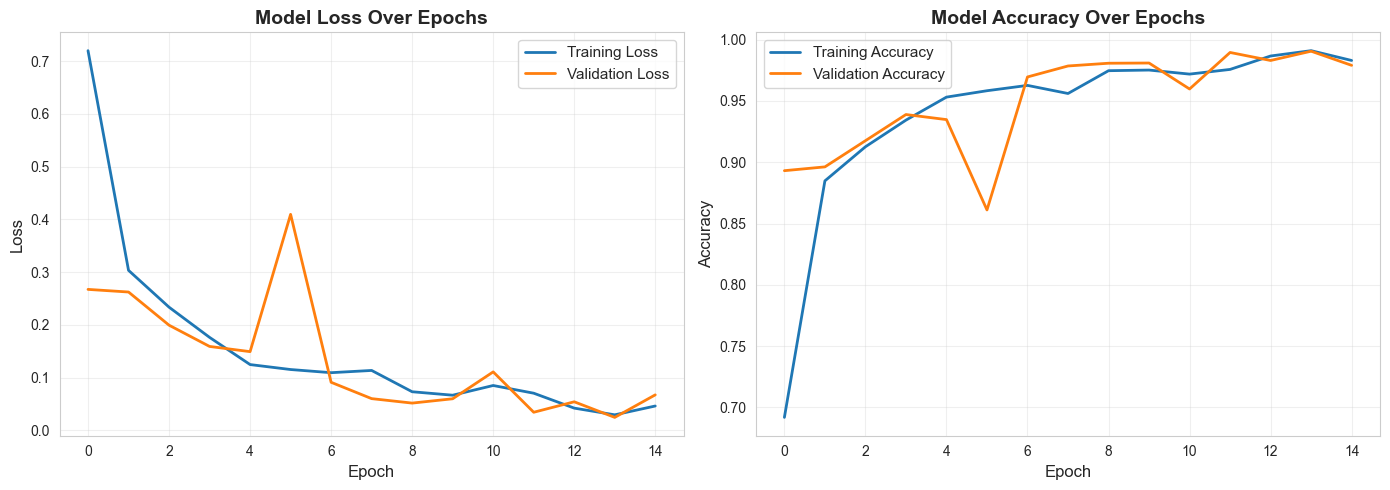

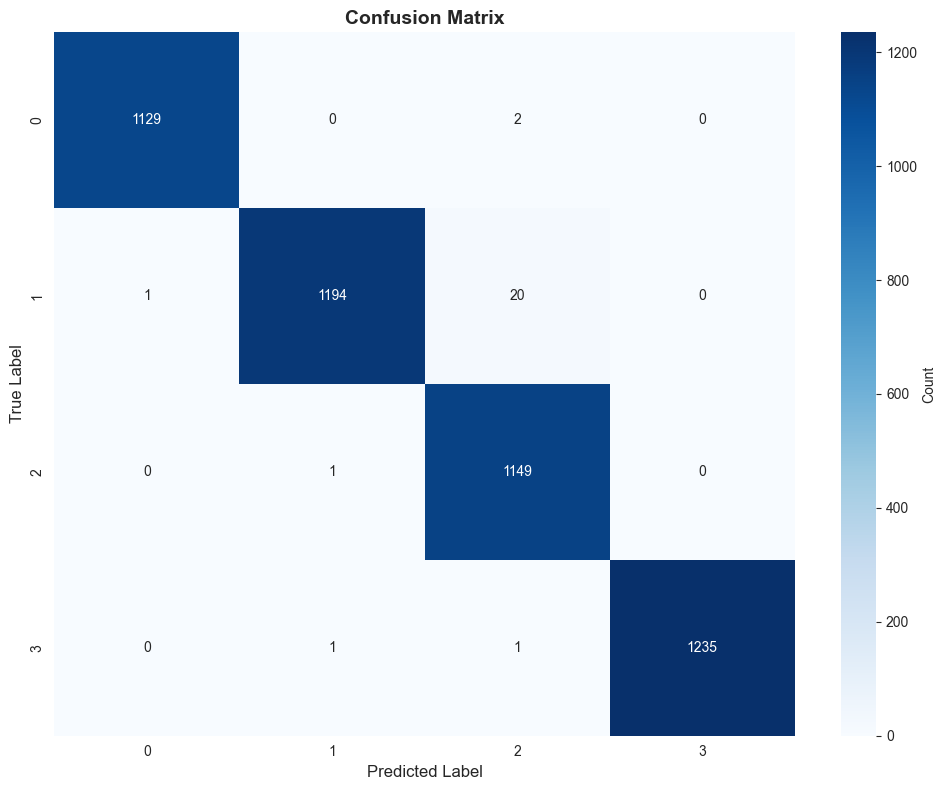


Per-Class Metrics from Confusion Matrix:
------------------------------------------------------------
Class 0         - Precision: 0.999, Recall: 0.998, F1: 0.999
Class 1         - Precision: 0.998, Recall: 0.983, F1: 0.990
Class 2         - Precision: 0.980, Recall: 0.999, F1: 0.990
Class 3         - Precision: 1.000, Recall: 0.998, F1: 0.999


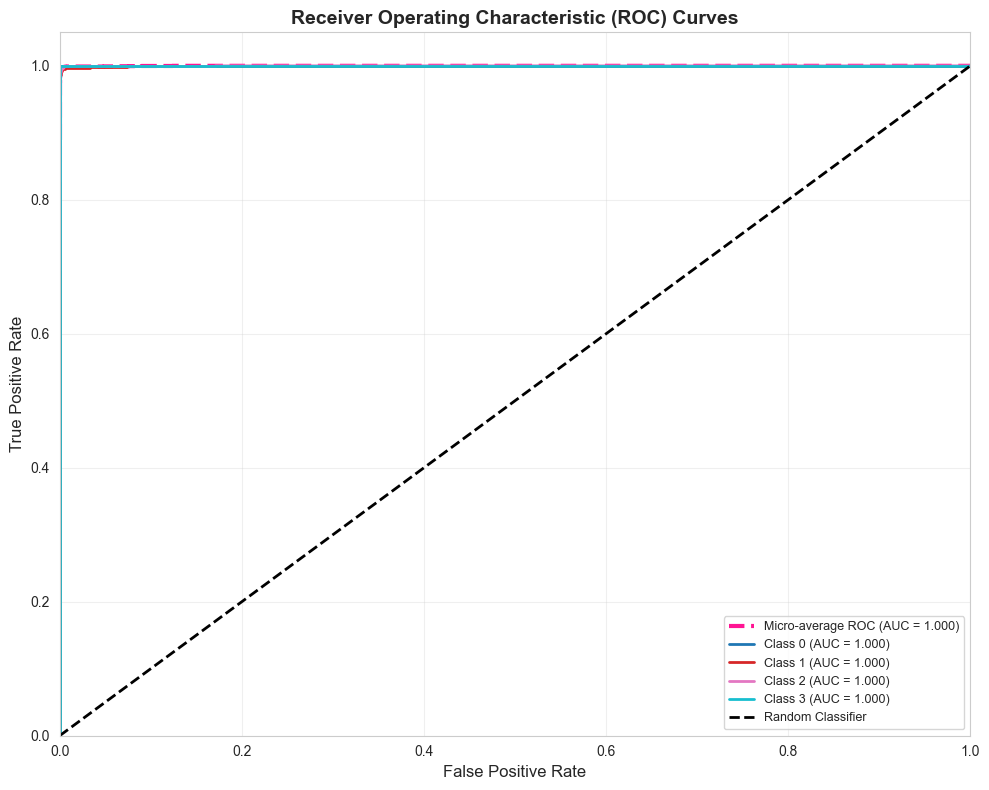


AUC Scores per Class:
----------------------------------------
Class 0        : 1.0000
Class 1        : 0.9996
Class 2        : 0.9996
Class 3        : 1.0000
Micro-average  : 0.9998

MODEL TRAINING SUMMARY
Training time: 12.41 minutes
Total epochs trained: 15
Final training accuracy: 0.9830
Final validation accuracy: 0.9790
Best validation accuracy: 0.9905

Simple CNN (baseline) Metrics:
Accuracy: 0.9945
Precision: 0.9946
Recall: 0.9945
F1_score: 0.9945


In [35]:
# ============================================
# 1. LEARNING CURVES
# ============================================
def plot_learning_curves(history):
    """Plot training and validation loss/accuracy"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curve
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curve
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_learning_curves(history)

# ============================================
# 2. CONFUSION MATRIX
# ============================================
def plot_confusion_matrix(y_true, y_pred, class_names=None):
    """Plot confusion matrix with annotations"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names if class_names else range(len(cm)),
                yticklabels=class_names if class_names else range(len(cm)),
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Calculate per-class metrics from confusion matrix
    print("\nPer-Class Metrics from Confusion Matrix:")
    print("-" * 60)
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        class_label = class_names[i] if class_names else f"Class {i}"
        print(f"{class_label:15s} - Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

# If you have class names, provide them here
# class_names = ['class1', 'class2', 'class3', ...]  # Replace with your actual class names
plot_confusion_matrix(y_true, y_pred, class_names=None)

# ============================================
# 3. ROC CURVES
# ============================================
def plot_roc_curves(y_true, y_prob, num_classes, class_names=None):
    """Plot ROC curves for multi-class classification"""
    # Ensure y_prob is a numpy array
    y_prob = np.array(y_prob) if not isinstance(y_prob, np.ndarray) else y_prob
    
    # Binarize the labels for multi-class ROC
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    
    # Plot micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
             color='deeppink', linestyle='--', linewidth=3)
    
    # Plot ROC curve for each class
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
    for i, color in zip(range(num_classes), colors):
        class_label = class_names[i] if class_names else f"Class {i}"
        plt.plot(fpr[i], tpr[i], color=color, linewidth=2,
                 label=f'{class_label} (AUC = {roc_auc[i]:.3f})')
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print AUC scores
    print("\nAUC Scores per Class:")
    print("-" * 40)
    for i in range(num_classes):
        class_label = class_names[i] if class_names else f"Class {i}"
        print(f"{class_label:15s}: {roc_auc[i]:.4f}")
    print(f"{'Micro-average':15s}: {roc_auc['micro']:.4f}")

plot_roc_curves(y_true, y_prob, NUM_CLASSES, class_names=None)

# ============================================
# 4. COMBINED METRICS SUMMARY
# ============================================
print("\n" + "="*60)
print("MODEL TRAINING SUMMARY")
print("="*60)
print(f"Training time: {train_time/60:.2f} minutes")
print(f"Total epochs trained: {len(history.history['loss'])}")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")

# Call your existing metrics function
metrics = compute_classification_metrics(y_true, y_pred, y_prob)
print_metrics_table(metrics, 'Simple CNN (baseline)')

### Experiment 8: MobileNet- CNN

This experiment implements a **MobileNet-inspired CNN** for image classification.  
The model is designed to be lightweight and efficient, making it faster to train and suitable for lower-RAM setups, while still achieving good accuracy.

### Model Highlights:
- Depthwise separable convolutions for reduced computation
- Batch normalization and ReLU activations
- Dropout for regularization
- Lightweight architecture for faster training and inference


🧪 Experiment 1 — Baseline MobileNet-style CNN
Epoch 1/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 36s 192ms/step - accuracy: 0.5866 - loss: 0.9513 - val_accuracy: 0.7791 - val_loss: 0.5927
Epoch 2/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 32s 177ms/step - accuracy: 0.7715 - loss: 0.5675 - val_accuracy: 0.8265 - val_loss: 0.4403
Epoch 3/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 26s 146ms/step - accuracy: 0.8242 - loss: 0.4399 - val_accuracy: 0.8626 - val_loss: 0.3405
Epoch 4/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 26s 144ms/step - accuracy: 0.8537 - loss: 0.3759 - val_accuracy: 0.8891 - val_loss: 0.2860
Epoch 5/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 26s 143ms/step - accuracy: 0.8791 - loss: 0.3048 - val_accuracy: 0.9065 - val_loss: 0.2442
Epoch 6/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 26s 143ms/step - accuracy: 0.8982 - loss: 0.2691 - val_accuracy: 0.9265 - val_loss: 0.1984
Epoch 7/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 26s 143ms/step - accuracy: 0.9173 - loss: 0.2179 - val_accuracy: 0.9143 - val_loss: 0.2132
Epoch 8/25
180/180 ━━━━━━━━━━━━━━━━━

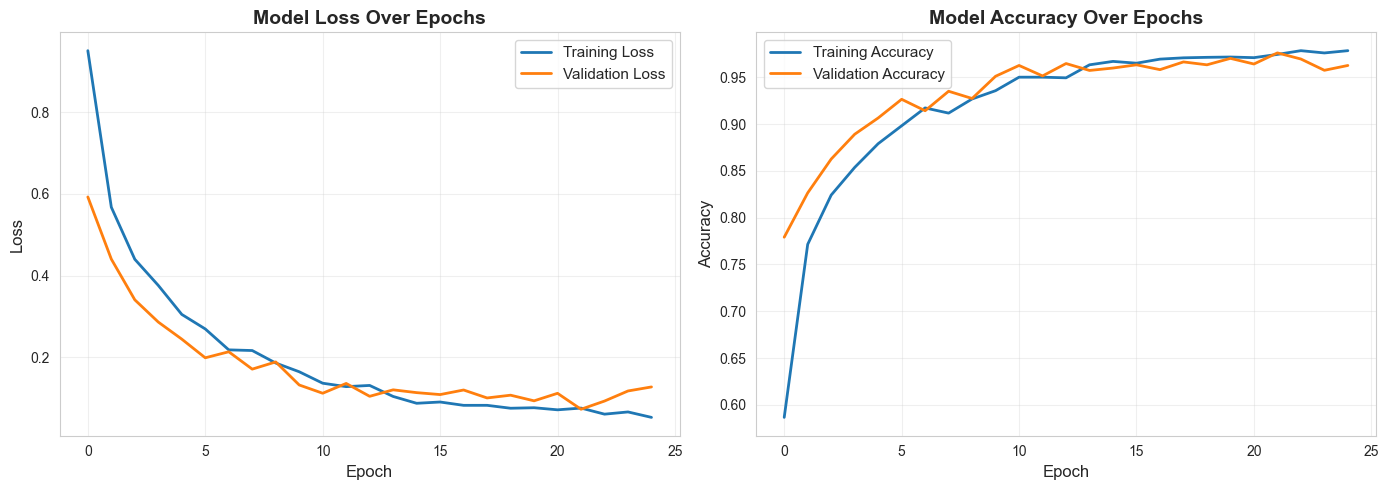


📊 Generating Confusion Matrix...


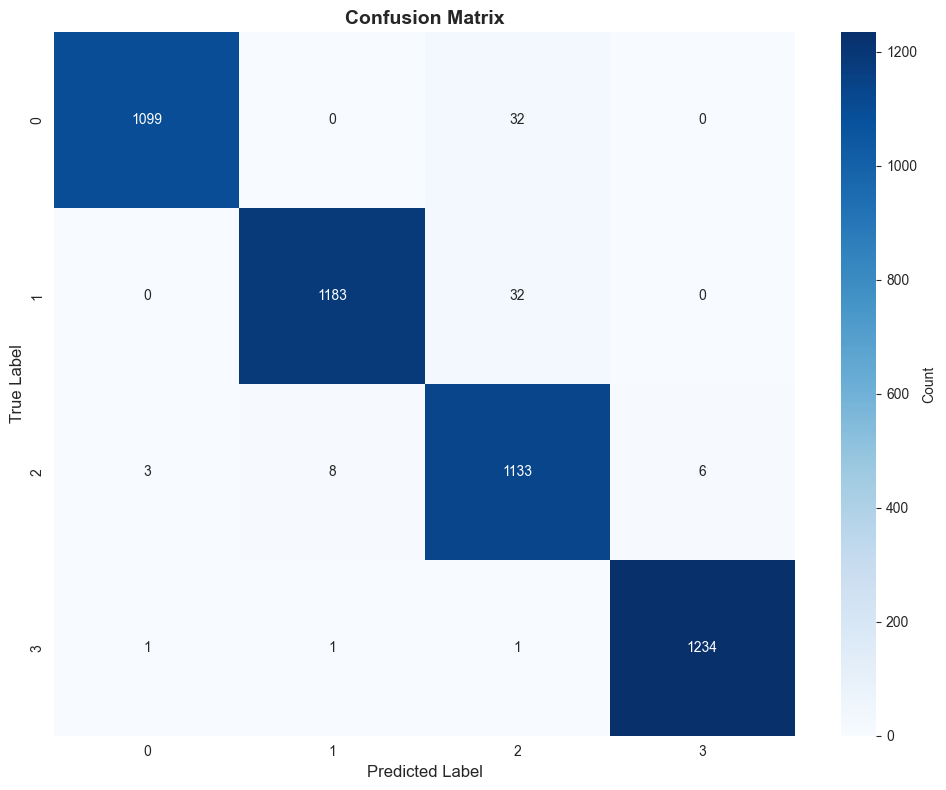


Per-Class Metrics from Confusion Matrix:
------------------------------------------------------------
Class 0         - Precision: 0.996, Recall: 0.972, F1: 0.984
Class 1         - Precision: 0.992, Recall: 0.974, F1: 0.983
Class 2         - Precision: 0.946, Recall: 0.985, F1: 0.965
Class 3         - Precision: 0.995, Recall: 0.998, F1: 0.996

📉 Generating ROC Curves...


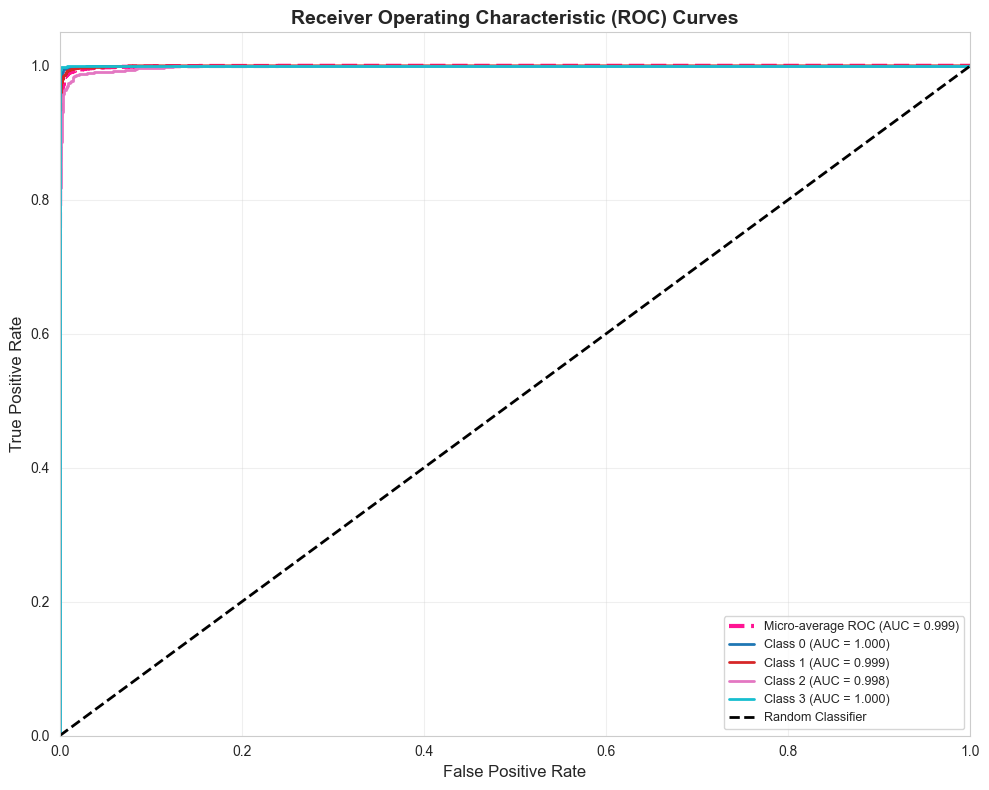


AUC Scores per Class:
----------------------------------------
Class 0        : 0.9997
Class 1        : 0.9993
Class 2        : 0.9980
Class 3        : 1.0000
Micro-average  : 0.9992

MODEL TRAINING SUMMARY
Training time: 13.45 minutes
Total epochs trained: 25
Final training accuracy: 0.9785
Final validation accuracy: 0.9626
Best validation accuracy: 0.9761

MobileNet-style CNN — Experiment 1 Metrics:
Accuracy: 0.9823
Precision: 0.9827
Recall: 0.9823
F1_score: 0.9823


In [39]:
from tensorflow.keras import layers, models, regularizers, callbacks, optimizers
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ===============================
# 🧠 MobileNet-style model builder
# ===============================
def build_mobilenet_style_cnn(
    input_shape=(config.IMG_SIZE_ML, config.IMG_SIZE_ML, 3),
    num_classes=NUM_CLASSES,
    l2_reg=0.0,
    dropout_rate=0.3
):
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    model = models.Sequential([
        layers.SeparableConv2D(
            32, (3,3), activation='relu', padding='same',
            input_shape=input_shape,
            depthwise_regularizer=reg,
            pointwise_regularizer=reg
        ),
        layers.MaxPooling2D(),
        layers.SeparableConv2D(
            64, (3,3), activation='relu', padding='same',
            depthwise_regularizer=reg,
            pointwise_regularizer=reg
        ),
        layers.MaxPooling2D(),
        layers.SeparableConv2D(
            128, (3,3), activation='relu', padding='same',
            depthwise_regularizer=reg,
            pointwise_regularizer=reg
        ),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# ===============================
# 📊 Visualization Functions
# ===============================
def plot_learning_curves(history, save_prefix=''):
    """Plot training and validation loss/accuracy"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curve
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curve
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{save_prefix}learning_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names=None, save_prefix=''):
    """Plot confusion matrix with annotations"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names if class_names else range(len(cm)),
                yticklabels=class_names if class_names else range(len(cm)),
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_prefix}confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Calculate per-class metrics from confusion matrix
    print("\nPer-Class Metrics from Confusion Matrix:")
    print("-" * 60)
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        class_label = class_names[i] if class_names else f"Class {i}"
        print(f"{class_label:15s} - Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

def plot_roc_curves(y_true, y_prob, num_classes, class_names=None, save_prefix=''):
    """Plot ROC curves for multi-class classification"""
    # Ensure y_prob is a numpy array
    y_prob = np.array(y_prob) if not isinstance(y_prob, np.ndarray) else y_prob
    
    # Binarize the labels for multi-class ROC
    y_true_bin = label_binarize(y_true, classes=range(num_classes))
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    
    # Plot micro-average ROC curve
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
             color='deeppink', linestyle='--', linewidth=3)
    
    # Plot ROC curve for each class
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
    for i, color in zip(range(num_classes), colors):
        class_label = class_names[i] if class_names else f"Class {i}"
        plt.plot(fpr[i], tpr[i], color=color, linewidth=2,
                 label=f'{class_label} (AUC = {roc_auc[i]:.3f})')
    
    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{save_prefix}roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print AUC scores
    print("\nAUC Scores per Class:")
    print("-" * 40)
    for i in range(num_classes):
        class_label = class_names[i] if class_names else f"Class {i}"
        print(f"{class_label:15s}: {roc_auc[i]:.4f}")
    print(f"{'Micro-average':15s}: {roc_auc['micro']:.4f}")

# ===============================
# 🧪 Experiment 1 — Baseline
# ===============================
print("\n==============================")
print("🧪 Experiment 1 — Baseline MobileNet-style CNN")
print("==============================")

mobilenet_exp1 = build_mobilenet_style_cnn(l2_reg=0.0, dropout_rate=0.3)
mobilenet_exp1.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb = [callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)]

start = time.time()
# ⚠️ IMPORTANT: Capture the history object and set verbose=1
history_exp1 = mobilenet_exp1.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=25,  # Increased for better learning curves
    callbacks=cb, 
    verbose=1
)
train_time_exp1 = time.time() - start

# Evaluation
y_true, y_pred, y_prob = [], [], []
for x, y in test_ds:
    preds = mobilenet_exp1.predict(x, verbose=0)
    y_true.extend(y.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())
    y_prob.extend(preds.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ===============================
# 📊 Generate all visualizations
# ===============================
# If you have class names, define them here:
# class_names = ['class1', 'class2', 'class3', ...]
class_names = None

# Plot learning curves
print("\n📈 Generating Learning Curves...")
plot_learning_curves(history_exp1, save_prefix='mobilenet_exp1_')

# Plot confusion matrix
print("\n📊 Generating Confusion Matrix...")
plot_confusion_matrix(y_true, y_pred, class_names=class_names, save_prefix='mobilenet_exp1_')

# Plot ROC curves
print("\n📉 Generating ROC Curves...")
plot_roc_curves(y_true, y_prob, NUM_CLASSES, class_names=class_names, save_prefix='mobilenet_exp1_')

# ===============================
# 📋 Summary
# ===============================
print("\n" + "="*60)
print("MODEL TRAINING SUMMARY")
print("="*60)
print(f"Training time: {train_time_exp1/60:.2f} minutes")
print(f"Total epochs trained: {len(history_exp1.history['loss'])}")
print(f"Final training accuracy: {history_exp1.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_exp1.history['val_accuracy'][-1]:.4f}")
print(f"Best validation accuracy: {max(history_exp1.history['val_accuracy']):.4f}")

# Your existing metrics
metrics_exp1 = compute_classification_metrics(y_true, y_pred, y_prob)
print_metrics_table(metrics_exp1, 'MobileNet-style CNN — Experiment 1')

### Experiment 9: Mobile Net  with lower LR and Higher Dropout


🧪 Experiment 2 — Regularized MobileNet-style CNN
Epoch 1/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.4989 - loss: 1.2114 - val_accuracy: 0.7323 - val_loss: 0.8286
Epoch 2/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 28s 156ms/step - accuracy: 0.7401 - loss: 0.7417 - val_accuracy: 0.8175 - val_loss: 0.5440
Epoch 3/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 33s 182ms/step - accuracy: 0.7904 - loss: 0.6150 - val_accuracy: 0.8282 - val_loss: 0.4918
Epoch 4/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 37s 204ms/step - accuracy: 0.8196 - loss: 0.5340 - val_accuracy: 0.8489 - val_loss: 0.4398
Epoch 5/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 35s 195ms/step - accuracy: 0.8309 - loss: 0.4861 - val_accuracy: 0.8681 - val_loss: 0.3865
Epoch 6/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 35s 195ms/step - accuracy: 0.8448 - loss: 0.4591 - val_accuracy: 0.8814 - val_loss: 0.3516
Epoch 7/25
180/180 ━━━━━━━━━━━━━━━━━━━━ 83s 463ms/step - accuracy: 0.8636 - loss: 0.4147 - val_accuracy: 0.8941 - val_loss: 0.3214
Epoch 8/25
180/180 ━━━━━━━━━━━━━━

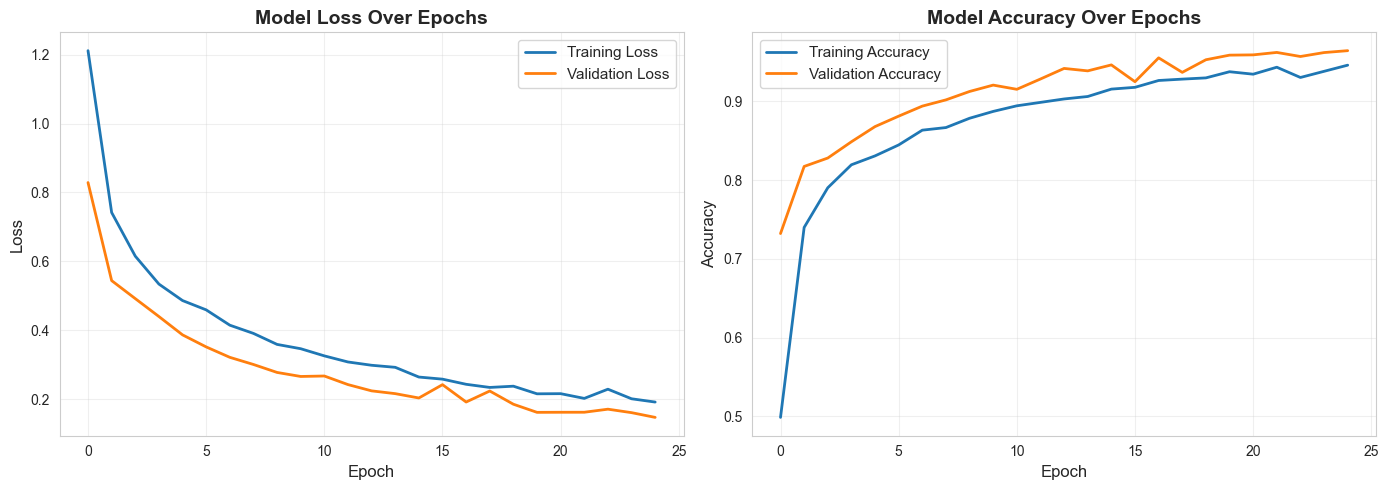


📊 Generating Confusion Matrix...


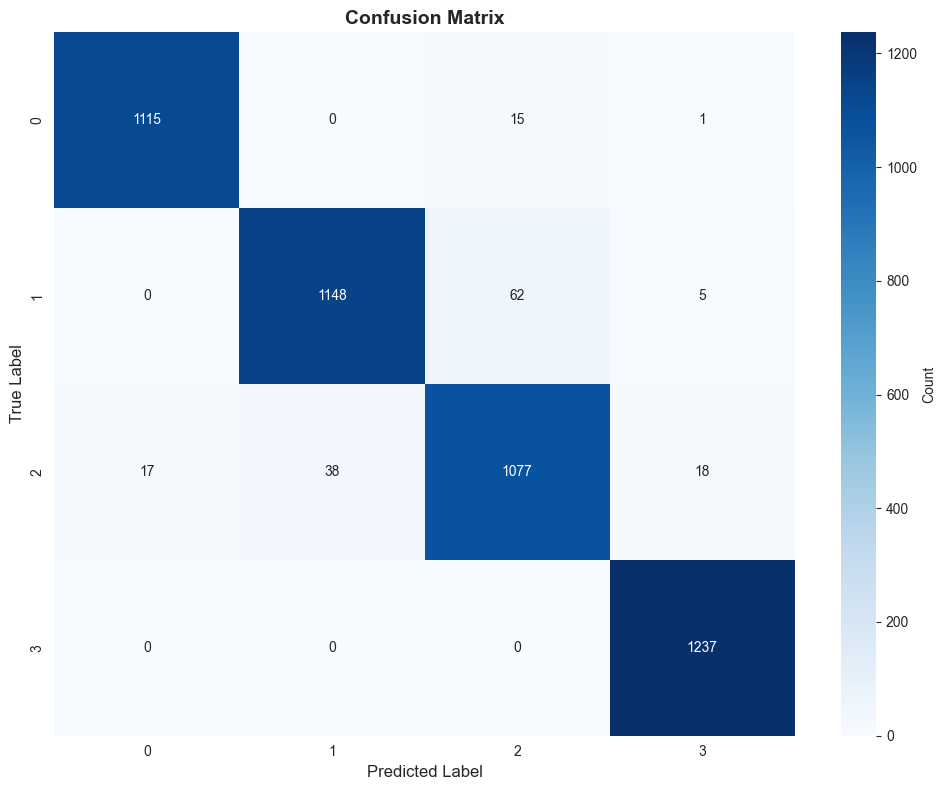


Per-Class Metrics from Confusion Matrix:
------------------------------------------------------------
Class 0         - Precision: 0.985, Recall: 0.986, F1: 0.985
Class 1         - Precision: 0.968, Recall: 0.945, F1: 0.956
Class 2         - Precision: 0.933, Recall: 0.937, F1: 0.935
Class 3         - Precision: 0.981, Recall: 1.000, F1: 0.990

📉 Generating ROC Curves...


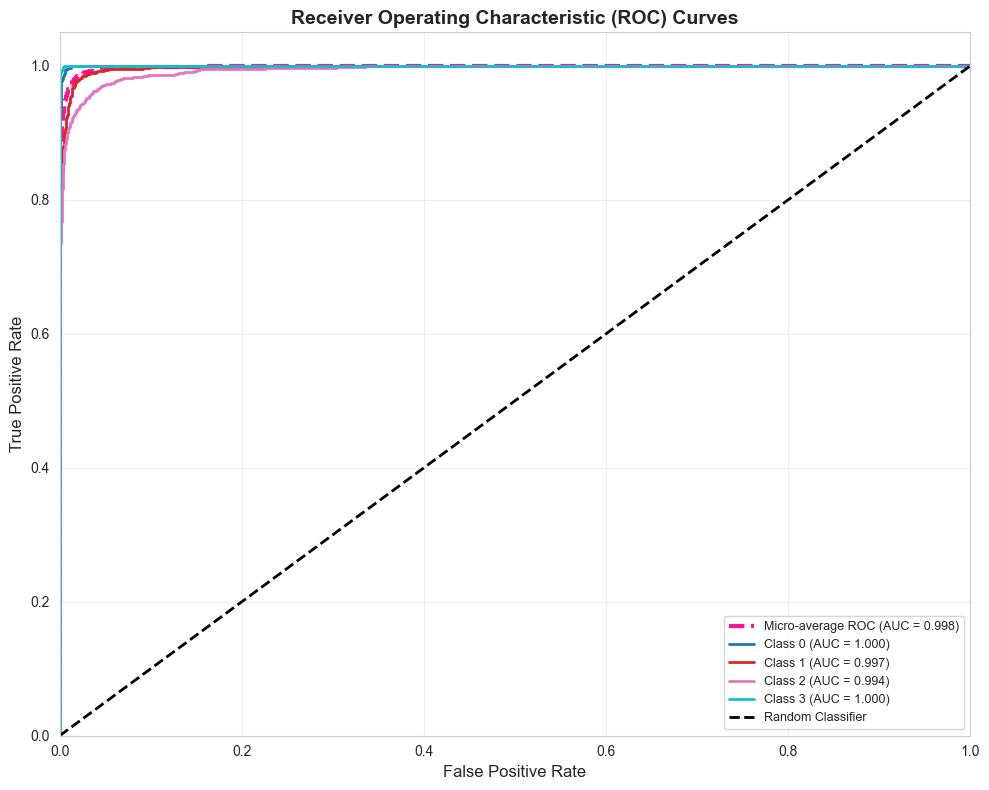


AUC Scores per Class:
----------------------------------------
Class 0        : 0.9996
Class 1        : 0.9973
Class 2        : 0.9940
Class 3        : 1.0000
Micro-average  : 0.9984

EXPERIMENT 2 - SUMMARY
Training time: 27.43 minutes
Epochs trained: 25
Best val accuracy: 0.9645

MobileNet-style CNN — Experiment 2 Metrics:
Accuracy: 0.9670
Precision: 0.9670
Recall: 0.9670
F1_score: 0.9670


In [44]:
# ===============================
# 🧪 Experiment 2 — Regularization + Lower LR + Higher Dropout
# ===============================
print("\n==============================")
print("🧪 Experiment 2 — Regularized MobileNet-style CNN")
print("==============================")

mobilenet_exp2 = build_mobilenet_style_cnn(l2_reg=0.001, dropout_rate=0.5)
mobilenet_exp2.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Update early stopping patience if you want more epochs
cb = [callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]

start = time.time()
history_exp2 = mobilenet_exp2.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=25,
    callbacks=cb, 
    verbose=1
)
train_time_exp2 = time.time() - start

# Evaluation
y_true_exp2, y_pred_exp2, y_prob_exp2 = [], [], []
for x, y in test_ds:
    preds = mobilenet_exp2.predict(x, verbose=0)
    y_true_exp2.extend(y.numpy().tolist())
    y_pred_exp2.extend(np.argmax(preds, axis=1).tolist())
    y_prob_exp2.extend(preds.tolist())

y_true_exp2 = np.array(y_true_exp2)
y_pred_exp2 = np.array(y_pred_exp2)
y_prob_exp2 = np.array(y_prob_exp2)

# ===============================
# 📊 Generate visualizations
# ===============================
class_names = None  # Set your class names here if you have them

print("\n📈 Generating Learning Curves...")
plot_learning_curves(history_exp2, save_prefix='mobilenet_exp2_')

print("\n📊 Generating Confusion Matrix...")
plot_confusion_matrix(y_true_exp2, y_pred_exp2, class_names=class_names, save_prefix='mobilenet_exp2_')

print("\n📉 Generating ROC Curves...")
plot_roc_curves(y_true_exp2, y_prob_exp2, NUM_CLASSES, class_names=class_names, save_prefix='mobilenet_exp2_')

# ===============================
# 📋 Summary
# ===============================
print("\n" + "="*60)
print("EXPERIMENT 2 - SUMMARY")
print("="*60)
print(f"Training time: {train_time_exp2/60:.2f} minutes")
print(f"Epochs trained: {len(history_exp2.history['loss'])}")
print(f"Best val accuracy: {max(history_exp2.history['val_accuracy']):.4f}")

metrics_exp2 = compute_classification_metrics(y_true_exp2, y_pred_exp2, y_prob_exp2)
print_metrics_table(metrics_exp2, 'MobileNet-style CNN — Experiment 2')